# Exploratory Data Analysis

## Source - University of Minnesota LakeBrowser
### Overview
Lake mapping and visualization project by the University of Minnesota to use landsat (1975-2015) and Sentinel2 (2017-today) remote sensing data to measure water clarity, clorophyll, and colored dissolved organic matter (CDOM) through the open water season (May-September).

https://lakes.rs.umn.edu/

https://water.rs.umn.edu/lakebrowser

https://github.com/GEMS-UMN/Exchange-Notebooks

## Data 

### Lake water quality data for 2017–2025 (GeoPackage for mapping, ZIP file)
This .zip is downloaded from the LakeBrowser site and is used to set lake geometries with 

### GEMS-UMN Exchange Notebooks landcover API
This API enables exploration of land cover data from the Land Change Monitoring, Assessment, and Projection (LCMAP) for Minnesota.

## Package Installation & Import

In [1]:
# Install if needed:
#%pip install requests pandas geopandas shapely rasterio pyproj tqdm matplotlib

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd



# landcover
from requests import Session
import sys
sys.path.append('..')
from api_key import key
from tqdm.notebook import tqdm
from shapely.geometry import shape, mapping
from rasterio.io import MemoryFile
from rasterio.mask import mask

## Load Lake Data

In [2]:
# read the .gpkg file using geopandas
lake_df = gpd.read_file("Data/Minnesota Lake Water Quality 2017-2025/Minnesota Lake Water Quality.gpkg")

print(lake_df.shape)
lake_df.head()

(12193, 257)


,MN_LK_NUM,unmlknum,umnlknum_o,dowlknum_1,RNAME_1,PWI_CLASS,AREA_BASIN,WETTYPE,X_UTM,Y_UTM,...,SD_202505,SD_202506,SD_202507,SD_202508,SD_202509,SD_202510,SD_20250601_0930,SD_20250720_0920,SD_20250726_0824,geometry
0,MN01000100,01000100,01000100,01000100,Pine,P,378.7,5.0,494106.8,5114750.1,...,2.63,2.4,2.87,3.11,2.42,2.37,2.72,2.80,2.95,"MULTIPOLYGON (((494787.31 5115730.423, 494845...."
1,MN01000200,01000200,01000200,01000200,Split Rock,P,31.1,5.0,487099.2,5139084.6,...,3.42,NaN,NaN,0.60,0.75,0.61,0.71,0.66,NaN,"MULTIPOLYGON (((487141.948 5138924.847, 487136..."
2,MN01000300,01000300,01000300,01000300,Sandabacka,P,42.6,5.0,489468.4,5155642.4,...,1.94,NaN,NaN,1.08,1.98,1.96,1.75,1.66,NaN,"MULTIPOLYGON (((489317.316 5155438.25, 489307...."
3,MN01000400,01000400,01000400,01000400,Dutch,P,39.8,5.0,489529.5,5155207.6,...,2.42,NaN,NaN,1.00,1.87,1.87,1.65,1.49,NaN,"MULTIPOLYGON (((489438.379 5155072.245, 489301..."
4,MN01000500,01000500,01000500,01000500,Rice,P,77.9,5.0,489579.0,5160179.9,...,2.11,NaN,NaN,NaN,NaN,1.36,NaN,NaN,NaN,"MULTIPOLYGON (((489206.368 5160048.737, 489107..."


In [3]:
# Referencing the Metadata pdf - keep only the columns of interest and rename
# CL_20250601_0930: Mean summer chlorophyll a (µg/L) for the year 2025 and the summer period (June 1 through September 30)

keep_cols = ["unmlknum", "RNAME_1", "PolyAcres", "geometry", "CL_202509", "CL_20250601_0930"]
lake_df = lake_df[keep_cols].copy()

# Rename columns
lake_df = lake_df.rename(columns={
    "unmlknum": "lake_id",
    "RNAME_1": "lake_name",
    "PolyAcres": "acres",
    "CL_202509": "chl_sept_2025",
    "CL_20250601_0930": "mean_chl_summer_2025"
})


In [4]:
lake_df.describe()
lake_df.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 12193 entries, 0 to 12192
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype   
---  ------                --------------  -----   
 0   lake_id               12193 non-null  object  
 1   lake_name             12193 non-null  object  
 2   acres                 12193 non-null  float64 
 3   geometry              12193 non-null  geometry
 4   chl_sept_2025         10789 non-null  float64 
 5   mean_chl_summer_2025  10890 non-null  float64 
dtypes: float64(3), geometry(1), object(2)
memory usage: 571.7+ KB


## Cleaning Lake Search Results
Run some preliminary cleaning steps to make sure the lake search results are in the right format, don't have duplicate rows, and are only those bodies of water considered "lakes" (>10 acres according to the MN DNR).

In [5]:
# make sure acres column is numberic
lake_df["acres"] = pd.to_numeric(lake_df["acres"], errors="coerce")

# drop any duplicates based on the id column
lake_df = lake_df.drop_duplicates(subset='lake_id')

# strip and lower name column
lake_df["lake_name"] = lake_df["lake_name"].str.lower().str.strip()

# filtering results to only include lakes >10 acres
lake_df = lake_df[lake_df["acres"] > 10]

# filter to only keep the lines with chlorophyll data
lake_df = lake_df.dropna(subset=['chl_sept_2025', 'mean_chl_summer_2025'])

lake_df.info()
lake_df.describe()

<class 'geopandas.geodataframe.GeoDataFrame'>
Index: 10343 entries, 0 to 12192
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype   
---  ------                --------------  -----   
 0   lake_id               10343 non-null  object  
 1   lake_name             10343 non-null  object  
 2   acres                 10343 non-null  float64 
 3   geometry              10343 non-null  geometry
 4   chl_sept_2025         10343 non-null  float64 
 5   mean_chl_summer_2025  10343 non-null  float64 
dtypes: float64(3), geometry(1), object(2)
memory usage: 565.6+ KB


,acres,chl_sept_2025,mean_chl_summer_2025
count,10343.000000,10343.00000,10343.000000
mean,272.283172,20.66221,20.263134
std,3938.199794,39.30788,37.482347
min,10.016918,0.80000,0.970000
25%,26.093106,3.87000,3.830000
50%,51.447391,6.77000,6.320000
75%,131.297351,21.54500,19.965000
max,301430.799589,866.18000,856.090000


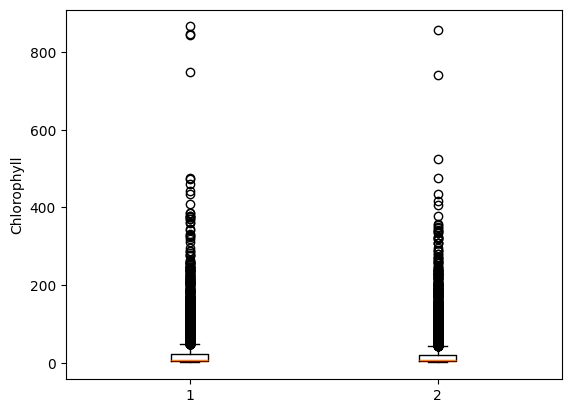

In [6]:
# simple boxplot of the lake chlorophyll to see general distribution
plt.boxplot([lake_df['chl_sept_2025'], lake_df['mean_chl_summer_2025']])
plt.ylabel('Chlorophyll')
plt.show()

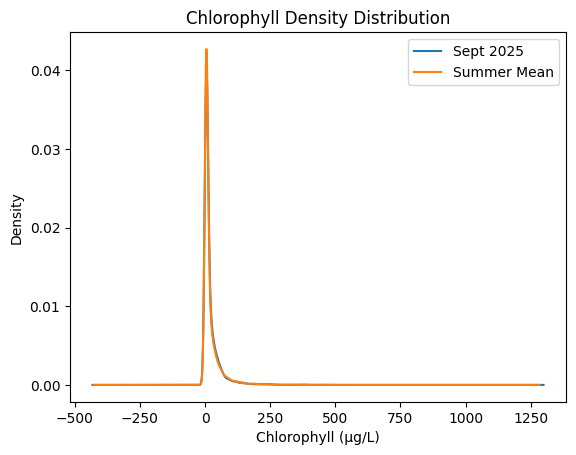

In [7]:
lake_df['chl_sept_2025'].plot(kind='density', label='Sept 2025')
lake_df['mean_chl_summer_2025'].plot(kind='density', label='Summer Mean')

plt.xlabel('Chlorophyll (µg/L)')
plt.title('Chlorophyll Density Distribution')
plt.legend()
plt.show()

In [8]:
# how many lakes have Chl over 100 
sept_high = (lake_df['chl_sept_2025'] > 100).sum()
summer_high = (lake_df['mean_chl_summer_2025'] > 100).sum()
print(sept_high, summer_high)

346 368


In [9]:
# filter to only include chlorophyll readings < 100 µg/L
lake_df = lake_df[lake_df["chl_sept_2025"] < 100]
lake_df = lake_df[lake_df["mean_chl_summer_2025"] < 100]

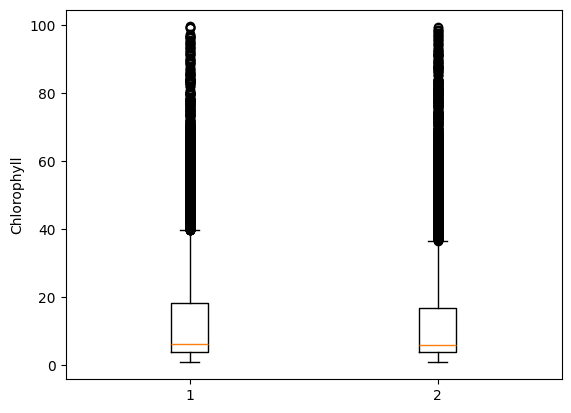

In [10]:
# looking at the box plot again
plt.boxplot([lake_df['chl_sept_2025'], lake_df['mean_chl_summer_2025']])
plt.ylabel('Chlorophyll')
plt.show()

In [11]:
# View the lakes with the 10 largest acreage
lake_df.sort_values("acres", ascending=False).head(10)

,lake_id,lake_name,acres,geometry,chl_sept_2025,mean_chl_summer_2025
7253,39000200,lake of the woods (main),301430.799589,"MULTIPOLYGON (((370906.346 5412785.616, 370887...",22.48,9.77
970,04003502,red (lower red),164535.449681,"MULTIPOLYGON (((364799.863 5319139.202, 364910...",7.33,7.89
7978,48000200,mille lacs,127870.835850,"MULTIPOLYGON (((454754.403 5134868.457, 454881...",4.90,4.59
969,04003501,red (upper red),119277.086176,"MULTIPOLYGON (((351498.168 5328042.723, 351523...",14.20,16.18
1859,11020301,leech (main basin),59642.207501,"MULTIPOLYGON (((401161.612 5220023.474, 401059...",3.94,3.93
1806,11014700,winnibigoshish,56769.271130,"MULTIPOLYGON (((400588.982 5250896.98, 400324....",3.41,3.15
10476,69069400,rainy,40772.364846,"MULTIPOLYGON (((488534.981 5382422.786, 488530...",3.91,3.47
10211,69037801,east vermilion,15822.495516,"MULTIPOLYGON (((552802.424 5297393.482, 552758...",6.31,5.40
8459,56024200,otter tail,14012.700880,"MULTIPOLYGON (((301634.758 5144882.949, 301629...",5.98,4.55
10594,69084501,kabetogama,12477.660351,"MULTIPOLYGON (((499988.501 5371635.54, 499737....",11.65,5.86


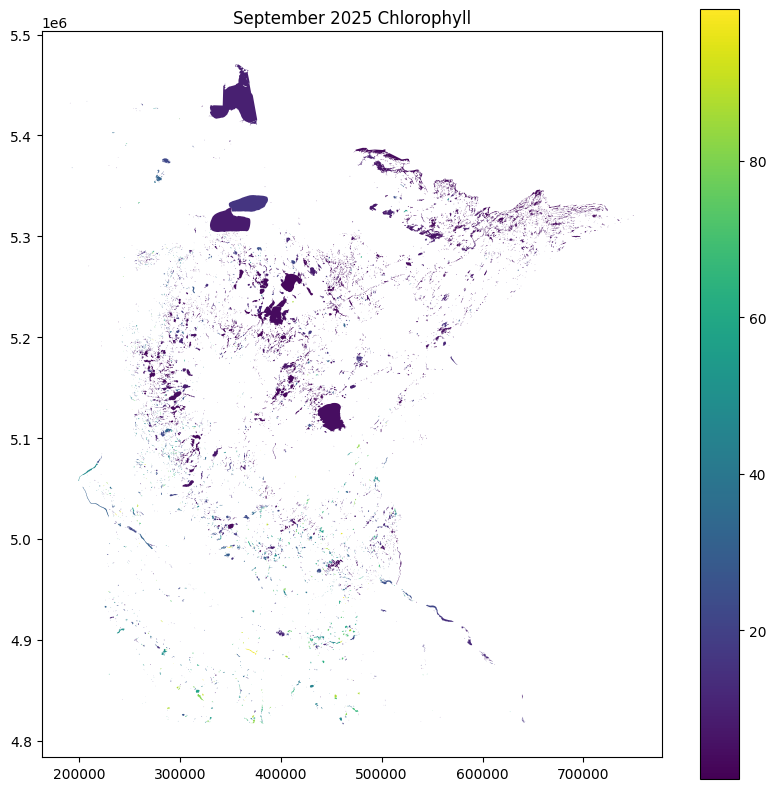

In [12]:
# simple map to view lake geometries and mean summer chlorophyll levels
lake_df.plot(
    column="mean_chl_summer_2025",
    legend=True,
    figsize=(10,10)
)
plt.title("September 2025 Chlorophyll")
plt.show()

## Buffer Zone Geometry
Create 50 meter buffer zone geometry around the lake geometry and calculate the acreage in that buffer zone

In [13]:
# API setup
s = Session()
s.headers.update({"apikey": key})
landcover_url = "https://exchange-1.gems.msi.umn.edu/landcover/v2"

# LCMAP classes
lcmap_classes = {
    0: "NoData",
    1: "Developed",
    2: "Cropland",
    3: "Grass_Shrub",
    4: "TreeCover",
    5: "Water",
    6: "Wetland",
    7: "Ice_Snow",
    8: "Barren"
}

# choose buffer distance
BUFFER_M = 50

# start from lake polygons
lakes_projected = lake_df.to_crs("EPSG:26915").copy()

# create ring buffer: surrounding area only, not including lake itself
buffer_geom = lakes_projected.geometry.buffer(BUFFER_M).difference(lakes_projected.geometry)

buffers_projected = gpd.GeoDataFrame(
    lakes_projected.drop(columns="geometry"),
    geometry=buffer_geom,
    crs="EPSG:26915"
)

buffers_projected["buffer_50m_acres"] = buffers_projected.geometry.area / 4046.8564224

# API search needs lon/lat geometry
buffers_api = buffers_projected.to_crs("EPSG:4326").copy()

print("Projected buffer bounds:", buffers_projected.total_bounds)
print("API buffer bounds:", buffers_api.total_bounds)
print("API CRS:", buffers_api.crs)

Projected buffer bounds: [ 190981.01745144 4816394.57418668  749711.52388301 5470502.51315321]
API buffer bounds: [-97.22183601  43.49553845 -89.65283953  49.37064425]
API CRS: EPSG:4326


In [14]:
# save buffer zone data as a .csv 
buffers_api.to_csv("Data/buffer_zone.csv", index=False)

## Connect to Landcover API 
AI assistance on this section to connect, pull, and save landcover data for each lake buffer zone

In [15]:
# API setup
s = Session()
s.headers.update({"apikey": key})
landcover_url = "https://exchange-1.gems.msi.umn.edu/landcover/v2"

# LCMAP classes
lcmap_classes = {
    0: "NoData",
    1: "Developed",
    2: "Cropland",
    3: "Grass_Shrub",
    4: "TreeCover",
    5: "Water",
    6: "Wetland",
    7: "Ice_Snow",
    8: "Barren"
}

## Helper functions for land-cover proportions in lake buffer zones

In [16]:
def bbox_string(geom):
    minx, miny, maxx, maxy = geom.bounds
    
    if not (-180 <= minx <= 180 and -180 <= maxx <= 180 and -90 <= miny <= 90 and -90 <= maxy <= 90):
        raise ValueError(f"Geometry is not lon/lat. Bounds: {geom.bounds}")
        
    return f"{minx},{miny},{maxx},{maxy}"


def get_lcmap_objects(geom_wgs84, limit=100):
    params = {
        "bbox": bbox_string(geom_wgs84),
        "limit": limit
    }
    
    r = s.get(f"{landcover_url}/lcmap-1.2/object/search", params=params)
    r.raise_for_status()
    
    df = pd.json_normalize(r.json())
    
    if df.empty:
        return df
    
    df["year"] = df["t_ranges"].apply(lambda x: int(x[0]["begin"][:4]))
    return df


def count_lcmap_pixels(object_id, geom_wgs84):
    params = {"bbox": bbox_string(geom_wgs84)}
    
    r = s.get(
        f"{landcover_url}/lcmap-1.2/object/{int(object_id)}/raster",
        params=params
    )
    
    if r.status_code in [400, 404, 422]:
        return {}
    
    r.raise_for_status()
    
    with MemoryFile(r.content) as memfile:
        with memfile.open() as dataset:
            
            geom_for_raster = geom_wgs84
            
            if dataset.crs is not None and dataset.crs.to_string() != "EPSG:4326":
                geom_for_raster = (
                    gpd.GeoSeries([geom_wgs84], crs="EPSG:4326")
                    .to_crs(dataset.crs)
                    .iloc[0]
                )
            
            out_image, _ = mask(
                dataset,
                [mapping(geom_for_raster)],
                crop=True,
                filled=True,
                all_touched=True
            )
            
            data = out_image[0]
            
            if dataset.nodata is not None:
                data = data[data != dataset.nodata]
            
            data = data[data != 0]
            
            values, counts = np.unique(data, return_counts=True)
            return dict(zip(values.astype(int), counts.astype(int)))


def landcover_proportions_for_buffer(row):
    geom_wgs84 = row.geometry
    
    objects = get_lcmap_objects(geom_wgs84)
    
    if objects.empty:
        return None
    
    latest_year = int(objects["year"].max())
    latest_objects = objects[objects["year"] == latest_year]
    
    counts = {class_name: 0 for class_name in lcmap_classes.values()}
    
    for _, obj in latest_objects.iterrows():
        pixel_counts = count_lcmap_pixels(obj["id"], geom_wgs84)
        
        for value, count in pixel_counts.items():
            class_name = lcmap_classes.get(value, f"class_{value}")
            counts[class_name] = counts.get(class_name, 0) + count
    
    total_pixels = sum(
        count for class_name, count in counts.items()
        if class_name != "NoData"
    )
    
    result = {
        "lake_id": row.get("lake_id", row.get("id", None)),
        "lake_name": row.get("lake_name", row.get("name", None)),
        "lcmap_year": latest_year,
        "buffer_50m_acres": row["buffer_50m_acres"],
        "total_landcover_pixels": total_pixels
    }
    
    for class_name, count in counts.items():
        result[f"{class_name}_count"] = count
        
        if class_name != "NoData":
            result[f"{class_name}_prop"] = count / total_pixels if total_pixels > 0 else np.nan
    
    return result

# Pull land use data for small sample to test

In [17]:
landuse_results = []
problem_lakes = []

buffer_sample = buffers_api.head(10).copy()

for _, row in tqdm(buffer_sample.iterrows(), total=len(buffer_sample)):
    try:
        result = landcover_proportions_for_buffer(row)
        
        if result is None:
            problem_lakes.append({
                "lake_id": row.get("lake_id", row.get("id", None)),
                "lake_name": row.get("lake_name", row.get("name", None)),
                "reason": "No LCMAP objects found"
            })
        else:
            landuse_results.append(result)
            
    except Exception as e:
        problem_lakes.append({
            "lake_id": row.get("lake_id", row.get("id", None)),
            "lake_name": row.get("lake_name", row.get("name", None)),
            "reason": str(e)
        })

landuse_df = pd.DataFrame(landuse_results)
problem_lakes_df = pd.DataFrame(problem_lakes)

landuse_df.head()

  0%|          | 0/10 [00:00<?, ?it/s]

,lake_id,lake_name,lcmap_year,buffer_50m_acres,total_landcover_pixels,NoData_count,Developed_count,Developed_prop,Cropland_count,Cropland_prop,...,TreeCover_count,TreeCover_prop,Water_count,Water_prop,Wetland_count,Wetland_prop,Ice_Snow_count,Ice_Snow_prop,Barren_count,Barren_prop
0,01000100,pine,2020,92.222570,4722,0,375,0.079416,368,0.077933,...,1607,0.340322,935,0.198009,1415,0.299661,0,0.0,0,0.0
1,01000200,split rock,2020,18.673337,940,0,0,0.000000,36,0.038298,...,184,0.195745,266,0.282979,448,0.476596,0,0.0,0,0.0
2,01000300,sandabacka,2020,17.117370,856,0,0,0.000000,0,0.000000,...,76,0.088785,122,0.142523,658,0.768692,0,0.0,0,0.0
3,01000400,dutch,2020,28.700297,1465,0,0,0.000000,0,0.000000,...,262,0.178840,239,0.163140,964,0.658020,0,0.0,0,0.0
4,01000600,mud,2020,14.415326,736,0,0,0.000000,0,0.000000,...,0,0.000000,145,0.197011,591,0.802989,0,0.0,0,0.0


# Pull land use data for all lakes

In [18]:
landuse_results = []
problem_lakes = []

for _, row in tqdm(buffers_api.iterrows(), total=len(buffers_api)):
    try:
        result = landcover_proportions_for_buffer(row)
        
        if result is None:
            problem_lakes.append({
                "lake_id": row.get("lake_id", row.get("id", None)),
                "lake_name": row.get("lake_name", row.get("name", None)),
                "reason": "No LCMAP objects found"
            })
        else:
            landuse_results.append(result)
            
    except Exception as e:
        problem_lakes.append({
            "lake_id": row.get("lake_id", row.get("id", None)),
            "lake_name": row.get("lake_name", row.get("name", None)),
            "reason": str(e)
        })

landuse_df = pd.DataFrame(landuse_results)
problem_lakes_df = pd.DataFrame(problem_lakes)

  0%|          | 0/9906 [00:00<?, ?it/s]

In [19]:
landuse_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9906 entries, 0 to 9905
Data columns (total 22 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   lake_id                 9906 non-null   object 
 1   lake_name               9906 non-null   object 
 2   lcmap_year              9906 non-null   int64  
 3   buffer_50m_acres        9906 non-null   float64
 4   total_landcover_pixels  9906 non-null   int64  
 5   NoData_count            9906 non-null   int64  
 6   Developed_count         9906 non-null   int64  
 7   Developed_prop          9906 non-null   float64
 8   Cropland_count          9906 non-null   int64  
 9   Cropland_prop           9906 non-null   float64
 10  Grass_Shrub_count       9906 non-null   int64  
 11  Grass_Shrub_prop        9906 non-null   float64
 12  TreeCover_count         9906 non-null   int64  
 13  TreeCover_prop          9906 non-null   float64
 14  Water_count             9906 non-null   

In [20]:
# save landuse data as a .csv
landuse_df.to_csv("Data/landuse_50m_buffers.csv", index=False)

In [21]:
landuse_df = pd.read_csv('Data/landuse_50m_buffers.csv')
landuse_df.head()
landuse_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9906 entries, 0 to 9905
Data columns (total 22 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   lake_id                 9906 non-null   object 
 1   lake_name               9906 non-null   object 
 2   lcmap_year              9906 non-null   int64  
 3   buffer_50m_acres        9906 non-null   float64
 4   total_landcover_pixels  9906 non-null   int64  
 5   NoData_count            9906 non-null   int64  
 6   Developed_count         9906 non-null   int64  
 7   Developed_prop          9906 non-null   float64
 8   Cropland_count          9906 non-null   int64  
 9   Cropland_prop           9906 non-null   float64
 10  Grass_Shrub_count       9906 non-null   int64  
 11  Grass_Shrub_prop        9906 non-null   float64
 12  TreeCover_count         9906 non-null   int64  
 13  TreeCover_prop          9906 non-null   float64
 14  Water_count             9906 non-null   

In [22]:
# Adding a categorical column with the majority land use category if there is a land use proportion that is > 0.5
prop_cols = [col for col in landuse_df.columns if col.endswith("_prop") and col != "NoData_prop"]

max_col = landuse_df[prop_cols].idxmax(axis=1)
max_val = landuse_df[prop_cols].max(axis=1)

landuse_df["majority_landuse"] = np.where(
    max_val > 0.5,
    max_col.str.replace("_prop", ""),
    "Mixed"
)

In [23]:
landuse_df.head()

,lake_id,lake_name,lcmap_year,buffer_50m_acres,total_landcover_pixels,NoData_count,Developed_count,Developed_prop,Cropland_count,Cropland_prop,...,TreeCover_prop,Water_count,Water_prop,Wetland_count,Wetland_prop,Ice_Snow_count,Ice_Snow_prop,Barren_count,Barren_prop,majority_landuse
0,01000100,pine,2020,92.222570,4722,0,375,0.079416,368,0.077933,...,0.340322,935,0.198009,1415,0.299661,0,0.0,0,0.0,Mixed
1,01000200,split rock,2020,18.673337,940,0,0,0.000000,36,0.038298,...,0.195745,266,0.282979,448,0.476596,0,0.0,0,0.0,Mixed
2,01000300,sandabacka,2020,17.117370,856,0,0,0.000000,0,0.000000,...,0.088785,122,0.142523,658,0.768692,0,0.0,0,0.0,Wetland
3,01000400,dutch,2020,28.700297,1465,0,0,0.000000,0,0.000000,...,0.178840,239,0.163140,964,0.658020,0,0.0,0,0.0,Wetland
4,01000600,mud,2020,14.415326,736,0,0,0.000000,0,0.000000,...,0.000000,145,0.197011,591,0.802989,0,0.0,0,0.0,Wetland


In [24]:
# counts for each majority land use type and the proportion
counts = landuse_df["majority_landuse"].value_counts()
props = landuse_df["majority_landuse"].value_counts(normalize=True)

summary_df = pd.DataFrame({
    "count": counts,
    "proportion": props
}).reset_index()

summary_df.columns = ["landuse_category", "count", "proportion"]
summary_df


,landuse_category,count,proportion
0,Mixed,3939,0.397638
1,TreeCover,3337,0.336867
2,Wetland,1415,0.142843
3,Water,652,0.065819
4,Cropland,326,0.032909
5,Developed,216,0.021805
6,Barren,18,0.001817
7,Grass_Shrub,3,0.000303


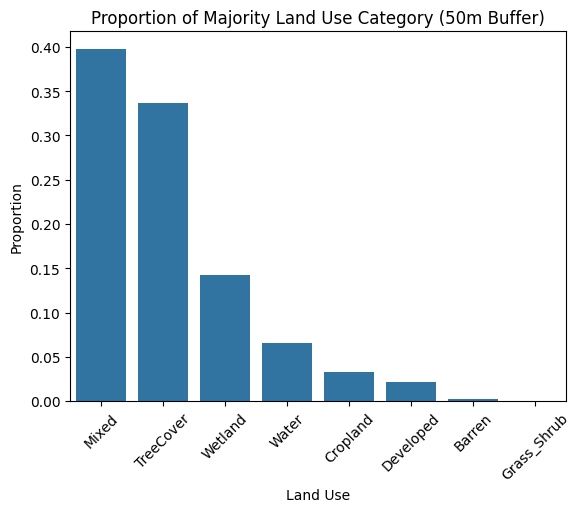

In [25]:
# plotting the proportion of majority land use category

majority_props = (
    landuse_df["majority_landuse"]
    .value_counts(normalize=True)   # gives proportions instead of counts
    .sort_values(ascending=False)
)


sns.barplot(
    x=majority_props.index,
    y=majority_props.values
)

plt.title("Proportion of Majority Land Use Category (50m Buffer)")
plt.ylabel("Proportion")
plt.xlabel("Land Use")
plt.xticks(rotation=45)

plt.show()

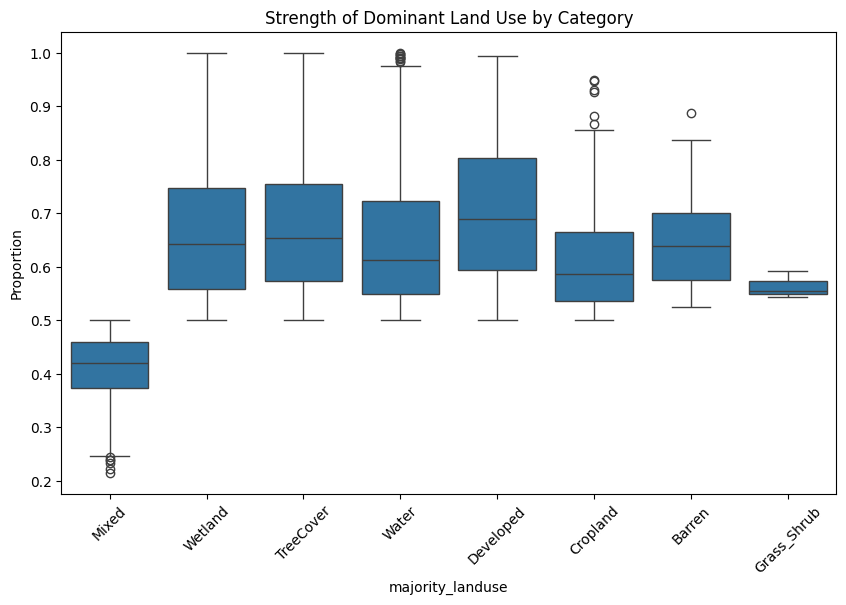

In [26]:
# Box plot showing the proportion of the majority category

prop_cols = [col for col in landuse_df.columns if col.endswith("_prop") and col != "NoData_prop"]

landuse_df["max_prop"] = landuse_df[prop_cols].max(axis=1)

plt.figure(figsize=(10,6))

sns.boxplot(
    data=landuse_df,
    x="majority_landuse",
    y="max_prop"
)

plt.title("Strength of Dominant Land Use by Category")
plt.ylabel("Proportion")
plt.xticks(rotation=45)

plt.show()

## Merge Water Quality and Land Use Data

In [27]:
lake_df.head()

,lake_id,lake_name,acres,geometry,chl_sept_2025,mean_chl_summer_2025
0,01000100,pine,373.578352,"MULTIPOLYGON (((494787.31 5115730.423, 494845....",6.64,5.07
1,01000200,split rock,23.564396,"MULTIPOLYGON (((487141.948 5138924.847, 487136...",12.07,13.35
2,01000300,sandabacka,27.635120,"MULTIPOLYGON (((489317.316 5155438.25, 489307....",3.85,4.06
3,01000400,dutch,43.687367,"MULTIPOLYGON (((489438.379 5155072.245, 489301...",4.02,4.42
5,01000600,mud,15.339665,"MULTIPOLYGON (((494876.945 5165227.598, 494831...",3.46,3.46


In [28]:
buffers_api.head()

,lake_id,lake_name,acres,chl_sept_2025,mean_chl_summer_2025,geometry,buffer_50m_acres
0,01000100,pine,373.578352,6.64,5.07,"POLYGON ((-93.07481 46.18449, -93.07475 46.184...",92.222570
1,01000200,split rock,23.564396,12.07,13.35,"POLYGON ((-93.16784 46.40648, -93.16781 46.406...",18.673337
2,01000300,sandabacka,27.635120,3.85,4.06,"POLYGON ((-93.13993 46.55221, -93.13995 46.552...",17.117370
3,01000400,dutch,43.687367,4.02,4.42,"POLYGON ((-93.13932 46.54837, -93.14063 46.547...",28.700297
5,01000600,mud,15.339665,3.46,3.46,"POLYGON ((-93.06697 46.64014, -93.06704 46.640...",14.415326


In [29]:
landuse_df.head()

,lake_id,lake_name,lcmap_year,buffer_50m_acres,total_landcover_pixels,NoData_count,Developed_count,Developed_prop,Cropland_count,Cropland_prop,...,Water_count,Water_prop,Wetland_count,Wetland_prop,Ice_Snow_count,Ice_Snow_prop,Barren_count,Barren_prop,majority_landuse,max_prop
0,01000100,pine,2020,92.222570,4722,0,375,0.079416,368,0.077933,...,935,0.198009,1415,0.299661,0,0.0,0,0.0,Mixed,0.340322
1,01000200,split rock,2020,18.673337,940,0,0,0.000000,36,0.038298,...,266,0.282979,448,0.476596,0,0.0,0,0.0,Mixed,0.476596
2,01000300,sandabacka,2020,17.117370,856,0,0,0.000000,0,0.000000,...,122,0.142523,658,0.768692,0,0.0,0,0.0,Wetland,0.768692
3,01000400,dutch,2020,28.700297,1465,0,0,0.000000,0,0.000000,...,239,0.163140,964,0.658020,0,0.0,0,0.0,Wetland,0.658020
4,01000600,mud,2020,14.415326,736,0,0,0.000000,0,0.000000,...,145,0.197011,591,0.802989,0,0.0,0,0.0,Wetland,0.802989


In [30]:
# merge lake and landuse dataframes
merged_df = landuse_df.merge(
    lake_df,
    on="lake_id",
    how="inner"   
)

In [31]:
print(merged_df.shape)
merged_df.head()

(9906, 29)


,lake_id,lake_name_x,lcmap_year,buffer_50m_acres,total_landcover_pixels,NoData_count,Developed_count,Developed_prop,Cropland_count,Cropland_prop,...,Ice_Snow_prop,Barren_count,Barren_prop,majority_landuse,max_prop,lake_name_y,acres,geometry,chl_sept_2025,mean_chl_summer_2025
0,01000100,pine,2020,92.222570,4722,0,375,0.079416,368,0.077933,...,0.0,0,0.0,Mixed,0.340322,pine,373.578352,"MULTIPOLYGON (((494787.31 5115730.423, 494845....",6.64,5.07
1,01000200,split rock,2020,18.673337,940,0,0,0.000000,36,0.038298,...,0.0,0,0.0,Mixed,0.476596,split rock,23.564396,"MULTIPOLYGON (((487141.948 5138924.847, 487136...",12.07,13.35
2,01000300,sandabacka,2020,17.117370,856,0,0,0.000000,0,0.000000,...,0.0,0,0.0,Wetland,0.768692,sandabacka,27.635120,"MULTIPOLYGON (((489317.316 5155438.25, 489307....",3.85,4.06
3,01000400,dutch,2020,28.700297,1465,0,0,0.000000,0,0.000000,...,0.0,0,0.0,Wetland,0.658020,dutch,43.687367,"MULTIPOLYGON (((489438.379 5155072.245, 489301...",4.02,4.42
4,01000600,mud,2020,14.415326,736,0,0,0.000000,0,0.000000,...,0.0,0,0.0,Wetland,0.802989,mud,15.339665,"MULTIPOLYGON (((494876.945 5165227.598, 494831...",3.46,3.46


In [32]:
# save merged table as a csv
merged_df.to_csv("Data/landuse_waterquality.csv", index=False)

## Land Use x Water Quality EDA

In [33]:
# creating a summary table with the count, median, mean, stdev chlorophyl value for each land use category
summary_table = (
    merged_df
    .groupby("majority_landuse")["chl_sept_2025"]
    .agg(
        count="count",
        mean="mean",
        median="median",
        std="std"
    )
    .reset_index()
)

summary_table

,majority_landuse,count,mean,median,std
0,Barren,18,7.611667,3.935,8.355256
1,Cropland,326,28.523712,22.010,21.717943
2,Developed,216,20.429954,11.445,19.840243
3,Grass_Shrub,3,31.310000,32.590,25.713905
4,Mixed,3939,17.621186,8.280,19.507237
5,TreeCover,3337,7.713917,4.140,9.972857
6,Water,652,25.161810,17.605,22.359135
7,Wetland,1415,13.687067,7.240,14.455810


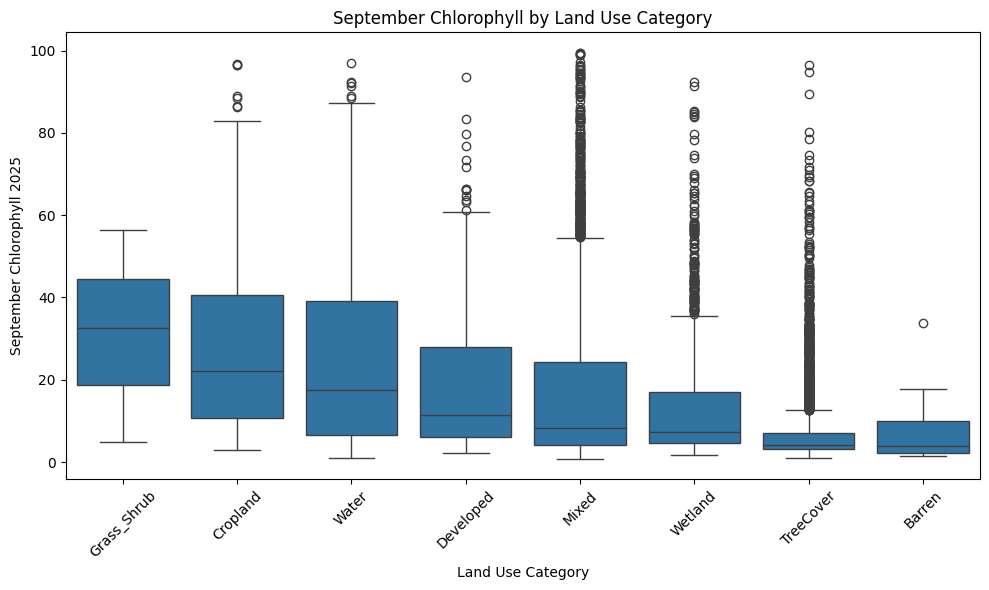

In [34]:
# box plot of September 2025 chlorophyll values for each land use category
category_order = (
    merged_df
    .groupby("majority_landuse")["chl_sept_2025"]
    .median()
    .sort_values(ascending=False)
    .index
)

plt.figure(figsize=(10,6))

sns.boxplot(
    data=merged_df,
    x="majority_landuse",
    y="chl_sept_2025",
    order=category_order
)

plt.title("September Chlorophyll by Land Use Category")
plt.xlabel("Land Use Category")
plt.ylabel("September Chlorophyll 2025")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

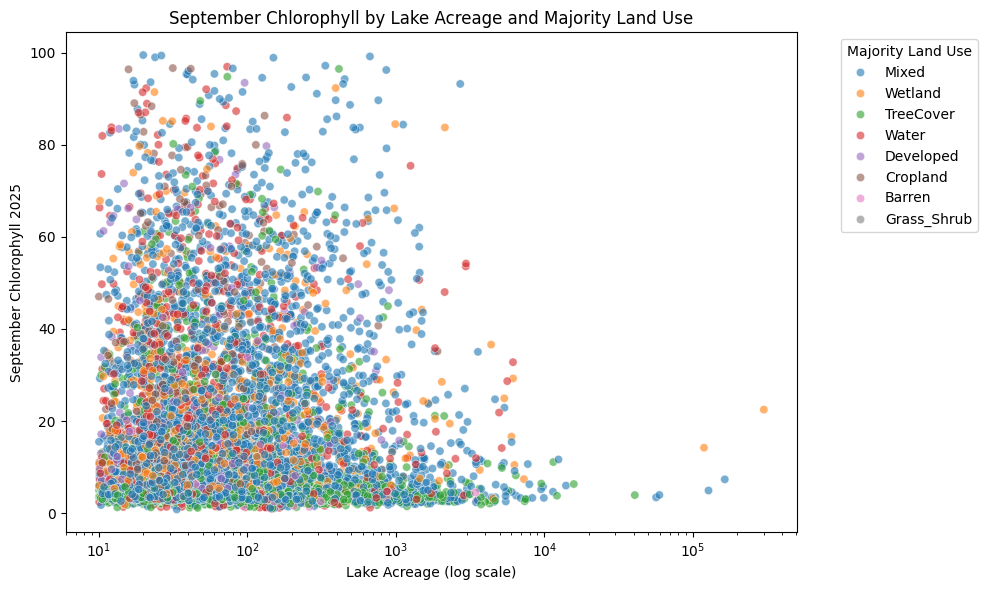

In [35]:
# Scatter plot of September Chlorophyll by Lake Acreage (log10 scale) and Majority Land Use

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=merged_df,
    x="acres",
    y="chl_sept_2025",
    hue="majority_landuse",
    alpha=0.6
)

plt.xscale("log")

plt.title("September Chlorophyll by Lake Acreage and Majority Land Use")
plt.xlabel("Lake Acreage (log scale)")
plt.ylabel("September Chlorophyll 2025")
plt.legend(title="Majority Land Use", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

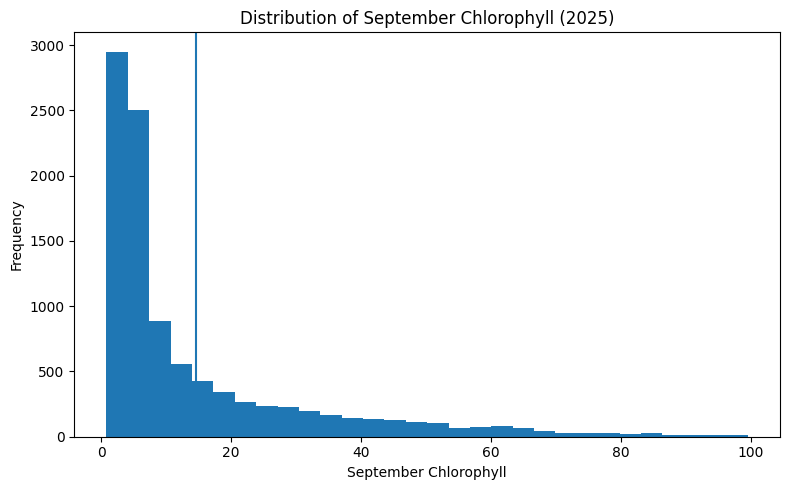

In [36]:
# histogram showing distribution of september 2025 chlorophyll values

chl = merged_df["chl_sept_2025"].dropna()
mean_val = chl.mean()

plt.figure(figsize=(8,5))
plt.hist(chl, bins=30)
plt.axvline(mean_val)
plt.title("Distribution of September Chlorophyll (2025)")
plt.xlabel("September Chlorophyll")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()